# Tasks remaining to do:

1. Encode the filename by using the encoder from wisio "https://github.com/izzet/wisio/blob/main/tools/recorder2parquet.cpp#L727"

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import yaml
from pathlib import Path
from dask.distributed import Client
import dask.dataframe as dd
import networkx as nx
import sys
import pandas as pd
import re
import glob


import ipycytoscape
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import intervals
import pygtrie
import seaborn as sns

/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
# App Name
app_name = "mummi5node" # resnet cosmoflow unet3d mummi deepspeed dlio_resnet dlio_cosmoflow


In [6]:

use_local=False
if not use_local:
    with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    # 1 with open(f'/g/g91/pandey2/.dlio_profiler/configuration.yaml', 'r') as file:
        dlp_yaml = yaml.safe_load(file)
        app_root = dlp_yaml["app"]
else:
    app_root = str(Path(os.getcwd()).parent.parent)
sys.path.insert(0, app_root)


import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
# from dfanalyzer.graph_visualization.plots import GrepIOPlots
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph import DFGrepInterference, DFGrepWorkflow 


if not use_local:
    dask_run_dir = os.path.join(app_root, "dfanalyzer", "dask", "run_dir")
    with open (os.path.join(dask_run_dir, f"scheduler_{os.getenv('USER')}.json"), "r") as f:
        dask_scheduler = json.load(f)["address"]
else:
    dask_scheduler = None





condition_fn = None #

if app_name == "mummi5node":
    # filename = "/usr/workspace/iopp/graph-io/dlp_logs/mummi-32-node/*pfw.gz"
    filename = "/usr/workspace/iopp/graph-io/dlp_logs/mummI-5_node-dlio-profiler/*.pfw.gz"
else:
    raise Exception("Unknown App name")


# Configuration 4 update log file dlp -> df
conf = update_dft_configuration(dask_scheduler=dask_scheduler, verbose=True, 
                                log_file=f"./dft_{os.getenv('USER')}.log", rebuild_index=False, time_approximate=False, 
                                host_pattern=r'lassen(\d+)', time_granularity=30e6, skip_hostname=True, conditions=condition_fn)
conf = get_dft_configuration()


# Setup
setup_logging()
setup_dask_cluster()
reset_dask_cluster()

[INFO] [05:30:20] Initialized Client with 768 workers and link http://134.9.71.28:8787/status [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:673]


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


[INFO] [05:30:31] Restarting all workers [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:665]


2024-09-26 09:32:06,171 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [7]:
# This cell is for mount point detection functions
def find_mount_point(path,trie):
    mount_point = trie.longest_prefix(path)
    if mount_point:
        return mount_point.key
    return "/"

def all_mount_points():
    with open("/proc/mounts", "r") as file:
        mount_points = [line.split()[1] for line in file]
    with open("/usr/workspace/pandey2/lassen_mounts", "r") as file:
        mount_p = [line.split()[1] for line in file]
    return mount_points+mount_p

mount_points = all_mount_points()
trie = pygtrie.StringTrie(zip(mount_points, [True] * len(mount_points)))

def mummi_cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
    d = {}
    def find_mount_point(path,trie):
        mount_point = trie.longest_prefix(path)
        if mount_point:
            return mount_point.key
        return "/"
    
    if "args" in json_object:
        if "filename" in json_object["args"]:
            d["filename"] = str(json_object["args"]["filename"])   
            d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=str(json_object["args"]["filename"]))
            
    if "name" in json_object:
        if (json_object["name"] == "write"):
            d["prod"] = 1
            d["cons"] = 0
        else:
            d["prod"] = 0
            d["cons"] = 1      
    
    return d

load_cols_mummi = {'filename':"string[pyarrow]",'mount_point':"string[pyarrow]", 'prod':"uint16[pyarrow]", 'cons':"uint16[pyarrow]"}


In [8]:
analyzer_mummi = DFAnalyzer(filename,load_fn=mummi_cols_function, load_cols=load_cols_mummi, load_data={"mount_point":trie})

[INFO] [05:30:48] Created index for 12 files [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:371]
[INFO] [05:30:48] Total size of all files are <dask.bag.core.Item object at 0x1554acb7ad30> bytes [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:373]
[INFO] [05:30:50] Loading 94 batches out of 12 files and has 1387329 lines overall [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:386]
[INFO] [05:30:59] Loaded events [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:431]
[INFO] [05:30:59] Loaded plots with slope threshold: 45 [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:437]


In [9]:
analyzer_mummi.events.head()

,name,cat,pid,tid,ts,te,dur,tinterval,trange,hostname,compute_time,io_time,app_io_time,total_time,filename,phase,size,mount_point,prod,cons
0,__xstat64,POSIX,101820,67217,25538,25554,16,<NA>,0,lassen493,<NA>,16,<NA>,16,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,2,<NA>,/p/gpfs1,0,1
1,__xstat64,POSIX,101820,67217,28687,28693,6,<NA>,0,lassen493,<NA>,6,<NA>,6,/tmp/mummi/cg/structure_iter01_000000000020-20...,2,<NA>,/tmp,0,1
2,__xstat64,POSIX,101820,67217,29794,29800,6,<NA>,0,lassen493,<NA>,6,<NA>,6,/tmp/mummi/cg/structure_iter01_000000000020-20...,2,<NA>,/tmp,0,1
3,open64,POSIX,101820,67217,30578,30627,49,<NA>,0,lassen493,<NA>,49,<NA>,49,/tmp/mummi/cg/structure_iter01_000000000020-20...,2,<NA>,/tmp,0,1
4,readlink,POSIX,101820,67217,31444,31453,9,<NA>,0,lassen493,<NA>,9,<NA>,9,/tmp/mummi/cg/structure_iter01_000000000020-20...,2,<NA>,/tmp,0,1


In [10]:
analyzer_mummi.events.pid.nunique().compute()

np.int64(2128)

In [11]:
analyzer_mummi.events.head()

,name,cat,pid,tid,ts,te,dur,tinterval,trange,hostname,compute_time,io_time,app_io_time,total_time,filename,phase,size,mount_point,prod,cons
0,__xstat64,POSIX,101820,67217,25538,25554,16,<NA>,0,lassen493,<NA>,16,<NA>,16,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,2,<NA>,/p/gpfs1,0,1
1,__xstat64,POSIX,101820,67217,28687,28693,6,<NA>,0,lassen493,<NA>,6,<NA>,6,/tmp/mummi/cg/structure_iter01_000000000020-20...,2,<NA>,/tmp,0,1
2,__xstat64,POSIX,101820,67217,29794,29800,6,<NA>,0,lassen493,<NA>,6,<NA>,6,/tmp/mummi/cg/structure_iter01_000000000020-20...,2,<NA>,/tmp,0,1
3,open64,POSIX,101820,67217,30578,30627,49,<NA>,0,lassen493,<NA>,49,<NA>,49,/tmp/mummi/cg/structure_iter01_000000000020-20...,2,<NA>,/tmp,0,1
4,readlink,POSIX,101820,67217,31444,31453,9,<NA>,0,lassen493,<NA>,9,<NA>,9,/tmp/mummi/cg/structure_iter01_000000000020-20...,2,<NA>,/tmp,0,1


In [12]:

# Mummi Graph
dfworkflow = DFGrepWorkflow(analyzer_mummi.events, app_name = "mummi", trace_path=filename)
#perform reduction
wf = dfworkflow.create_workflow()
pid_map = dfworkflow.get_pid_map()
graph_df = dfworkflow.create_graph_df(wf.compute(),pid_map)
temp_graph = graph_df.groupby(['src','dest'])['wt'].min().reset_index()
# temp_graph.sort_values('wt')

In [13]:
wf.compute()

,filename,pid,prod_pid,cons_pid,ts,prod_fid,cons_fid
0,/tmp/mummi/cg/structure_iter01_000000000020-20...,101820,3623,3633,28687,4043,4053
1,/tmp/mummi/cg/structure_iter01_000000000020-20...,101820,3627,3627,38726,4257,4257
2,/tmp/mummi/cg/structure_iter01_000000000020-20...,102630,9,9,73312245,4257,4257
3,/tmp/mummi/cg/structure_iter01_000000000020-20...,102630,6,6,73314867,4043,4053
4,/tmp/mummi/cg/structure_iter01_000000000020-20...,103001,9,9,112653521,4257,4257
...,...,...,...,...,...,...,...
2380,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,76673,3,34,32616879,3,50
2384,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,76673,3,34,32828382,3,50
3616,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,61771,0,190,175253868,1,202
3617,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,61771,0,88,175259630,1,100


In [14]:
graph_finer = dfworkflow.create_graph_finer_granularity(wf.compute())

In [16]:
temp_graph

,src,dest,wt
0,f_analysis.tar.pytree,p_100156,3788575239
1,f_analysis.tar.pytree,p_100429,431498005
2,f_analysis.tar.pytree,p_100542,3830025829
3,f_analysis.tar.pytree,p_100885,474994786
4,f_analysis.tar.pytree,p_101061,3871511424
...,...,...,...
2773,p_cganalysis,f_cg_analysis.log,24235
2774,p_cganalysis,f_cg_analysis.out,34367
2775,p_cganalysis,f_positions.tar.pytree,254181642
2776,p_createsims,f_createsims_success,1856304157


In [15]:
graph_finer

,src,dest,wt
0,/tmp/mummi/cg/structure_iter01_000000000020-20...,p_101820,28687
1,p_101820,/tmp/mummi/cg/structure_iter01_000000000020-20...,28687
2,/tmp/mummi/cg/structure_iter01_000000000020-20...,p_101820,38726
3,p_101820,/tmp/mummi/cg/structure_iter01_000000000020-20...,38726
4,/tmp/mummi/cg/structure_iter01_000000000020-20...,p_102630,73312245
...,...,...,...
2819,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,p_76673,32828382
2820,p_76673,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,32828382
2821,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,p_61771,175253868
2822,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,p_61771,175259630


In [17]:
betweeness_finer = dfworkflow.compute_betweeness_centrality(graph_finer)

In [18]:
betweness_app = dfworkflow.compute_betweeness_centrality(temp_graph)

In [19]:
graph_finer.to_csv("/p/lustre2/pandey2/cp_centrality/mummi/mummi5node/graph_finer.csv")
temp_graph.to_csv("/p/lustre2/pandey2/cp_centrality/mummi/mummi5node/graph_app.csv")

In [20]:
json.dump(betweeness_finer, open('/p/lustre2/pandey2/cp_centrality/mummi/mummi5node/betweeness_finer.txt','w'), indent=4)
json.dump(betweness_app, open('/p/lustre2/pandey2/cp_centrality/mummi/betweeness_app.txt','w'), indent=4)

In [21]:
analyzer_mummi.events.query("pid == 98936").compute()

,name,cat,pid,tid,ts,te,dur,tinterval,trange,hostname,compute_time,io_time,app_io_time,total_time,filename,phase,size,mount_point,prod,cons
15291,readlink,POSIX,98936,67217,297762098,297762136,38,<NA>,9,lassen170,<NA>,38,<NA>,38,/tmp/mummi/cg/structure_iter01_000000000042-20...,2,<NA>,/tmp,0,1
15292,write,POSIX,98936,67217,297763745,297763800,55,<NA>,9,lassen170,<NA>,55,<NA>,55,/tmp/mummi/cg/structure_iter01_000000000042-20...,2,229,/tmp,1,0
15293,readlink,POSIX,98936,67217,297765318,297765334,16,<NA>,9,lassen170,<NA>,16,<NA>,16,/tmp/mummi/cg/structure_iter01_000000000042-20...,2,<NA>,/tmp,0,1
15294,write,POSIX,98936,67217,297766651,297766673,22,<NA>,9,lassen170,<NA>,22,<NA>,22,/tmp/mummi/cg/structure_iter01_000000000042-20...,2,229,/tmp,1,0
15295,open64,POSIX,98936,67217,297770404,297770437,33,<NA>,9,lassen170,<NA>,33,<NA>,33,/tmp/mummi/cg/structure_iter01_000000000042-20...,2,<NA>,/tmp,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,write,POSIX,98936,67217,317251549,317251574,25,<NA>,10,lassen170,<NA>,25,<NA>,25,/tmp/mummi/cg/structure_iter01_000000000042-20...,2,163,/tmp,1,0
748,readlink,POSIX,98936,67217,317253596,317253617,21,<NA>,10,lassen170,<NA>,21,<NA>,21,/tmp/mummi/cg/structure_iter01_000000000042-20...,2,<NA>,/tmp,0,1
749,write,POSIX,98936,67217,317255067,317255094,27,<NA>,10,lassen170,<NA>,27,<NA>,27,/tmp/mummi/cg/structure_iter01_000000000042-20...,2,128,/tmp,1,0
750,readlink,POSIX,98936,67217,317257328,317257344,16,<NA>,10,lassen170,<NA>,16,<NA>,16,/tmp/mummi/cg/structure_iter01_000000000042-20...,2,<NA>,/tmp,0,1


In [64]:
pid_map['25135']

'createsims'

In [66]:
pid_map['19210']

'createsims'

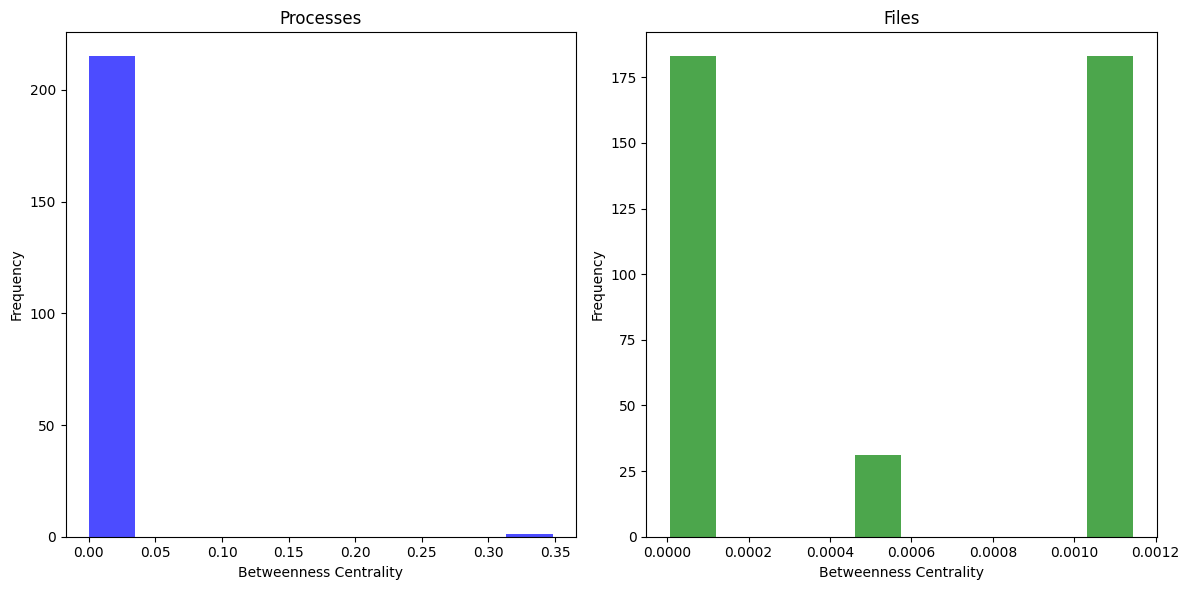

In [49]:
histogram_dict(betweeness_finer)

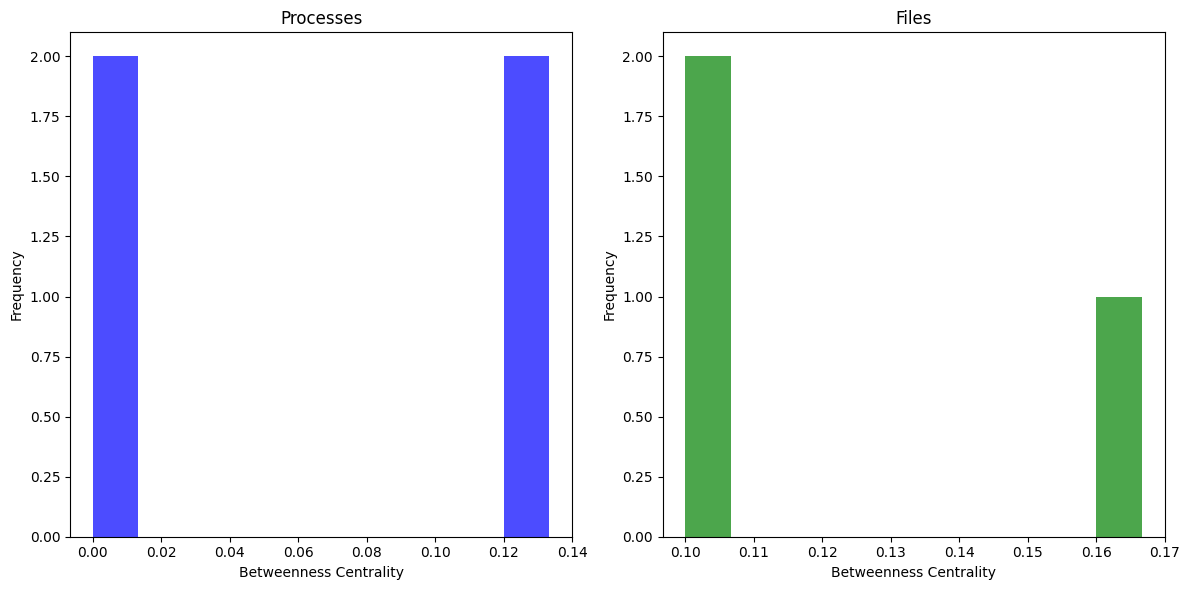

In [48]:
histogram_dict(betweness_app)

In [47]:
def histogram_dict(betweeness_dict):
    p_nodes = [value for node, value in betweeness_dict.items() if node.startswith('p')]
    f_nodes = [value for node, value in betweeness_dict.items() if not node.startswith('p')]
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Plotting histogram for p-nodes
    ax1.hist(p_nodes, bins=10, alpha=0.7, color='blue')
    # ax1.set_xscale('log')
    ax1.set_xlabel('Betweenness Centrality')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Processes')

    # Plotting histogram for non p-nodes
    ax2.hist(f_nodes, bins=10, alpha=0.7, color='green')
    # ax2.set_xscale('log')
    ax2.set_xlabel('Betweenness Centrality')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Files')

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()
    

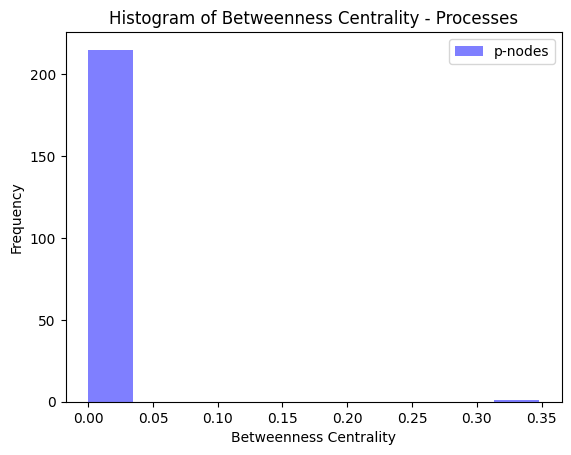

In [38]:
# Separate nodes into two groups based on whether they start with 'p'
p_nodes = [value for node, value in betweeness_finer.items() if node.startswith('p')]
f_nodes = [value for node, value in betweeness_finer.items() if not node.startswith('p')]

# Plotting histograms for both groups
plt.hist(p_nodes, bins=10, alpha=0.5, label='p-nodes', color='blue')
# plt.hist(f_nodes, bins=10, alpha=0.5, label='f-nodes', color='green')
# plt.xscale('log')
# Add labels and title
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')
plt.title('Histogram of Betweenness Centrality - Processes')
plt.legend()

# Show plot
plt.show()

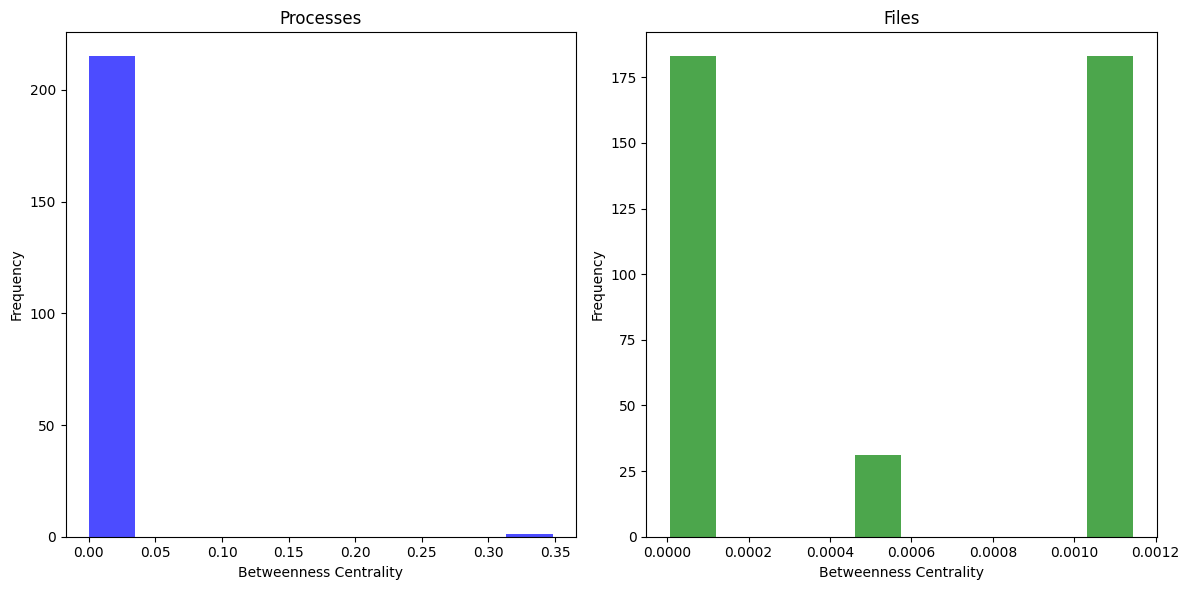

In [39]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plotting histogram for p-nodes
ax1.hist(p_nodes, bins=10, alpha=0.7, color='blue')
# ax1.set_xscale('log')
ax1.set_xlabel('Betweenness Centrality')
ax1.set_ylabel('Frequency')
ax1.set_title('Processes')

# Plotting histogram for non p-nodes
ax2.hist(f_nodes, bins=10, alpha=0.7, color='green')
# ax2.set_xscale('log')
ax2.set_xlabel('Betweenness Centrality')
ax2.set_ylabel('Frequency')
ax2.set_title('Files')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [13]:
graph_df

,src,dest,wt
0,f_structure_iterx_x.npz,p_createsims,17988
1,f_createsims_success,p_createsims,1961038225
2,p_createsims,f_createsims_success,1961038225
3,f_structure_iterx_x.npz,p_createsims,16980
4,f_createsims_success,p_createsims,1906060776
...,...,...,...
1186,p_createsims,f_createsims_success,2729530946
1187,f_structure_iterx_x.npz,p_createsims,20063
1188,f_structure_iterx_x.npz,p_createsims,14020
1189,f_createsims_failure,p_createsims,139208049


In [13]:
graph_df.to_csv("mummi_gdf.csv", index=False)

In [73]:
ct_0 = 0
ct_1 = 0
for key,val in betweeness_finer.items():
    k = key[2:]
    if k in pid_map.keys() and pid_map[k] == "cganalysis":
        if val == 0:
            ct_0 += 1
        else: 
            ct_1 += 1

print(ct_0, ct_1)

0 2


In [10]:
temp_graph

,src,dest,wt
0,f_createsims_failure,p_14251,85904186
1,f_createsims_failure,p_cganalysis,81780740
2,f_createsims_failure,p_createsims,76894074
3,f_createsims_success,p_14251,85904283
4,f_createsims_success,p_cganalysis,1890849941
5,f_createsims_success,p_createsims,1661884098
6,f_structure_iterx_x.npz,p_cganalysis,19954
7,f_structure_iterx_x.npz,p_createsims,12624
8,f_structure_iterx_x.npz,p_mlserver,29359864
9,p_cganalysis,f_createsims_failure,81780740


In [11]:
temp_graph.sort_values('wt')

,src,dest,wt
7,f_structure_iterx_x.npz,p_createsims,12624
6,f_structure_iterx_x.npz,p_cganalysis,19954
13,p_mlserver,f_structure_iterx_x.npz,29359864
8,f_structure_iterx_x.npz,p_mlserver,29359864
2,f_createsims_failure,p_createsims,76894074
11,p_createsims,f_createsims_failure,76894074
9,p_cganalysis,f_createsims_failure,81780740
1,f_createsims_failure,p_cganalysis,81780740
0,f_createsims_failure,p_14251,85904186
3,f_createsims_success,p_14251,85904283


In [18]:
temp_graph.to_csv("mummi_sort.csv", index=False)

In [14]:
# tg = temp_graph.sort_values('wt').reset_index(drop = True)
# tg['trange'] = tg.index
# c = CytoGraph()
# c.temporal_view(tg)

In [15]:
ealist = []
for row in range(len(temp_graph)):
    # print(len(tg.src.loc[row]) > len(tg.dest.loc[row]))
    if(temp_graph.src.loc[row].startswith("f")):
        ealist.append((temp_graph.src.loc[row],str(temp_graph.wt.loc[row])+" "+ str(temp_graph.dest.loc[row])))
    else:
        ealist.append((str(temp_graph.wt.loc[row])+" "+ str(temp_graph.src.loc[row]), temp_graph.dest.loc[row]))

df = pd.DataFrame()
df['src'] = [ealist[i][0] for i in range(len(ealist))]
df['dest'] = [ealist[i][1] for i in range(len(ealist))]
df['wt'] = temp_graph['wt']
df

,src,dest,wt
0,f_createsims_failure,85904186 p_14251,85904186
1,f_createsims_failure,81780740 p_cganalysis,81780740
2,f_createsims_failure,76894074 p_createsims,76894074
3,f_createsims_success,85904283 p_14251,85904283
4,f_createsims_success,1890849941 p_cganalysis,1890849941
5,f_createsims_success,1661884098 p_createsims,1661884098
6,f_structure_iterx_x.npz,19954 p_cganalysis,19954
7,f_structure_iterx_x.npz,12624 p_createsims,12624
8,f_structure_iterx_x.npz,29359864 p_mlserver,29359864
9,81780740 p_cganalysis,f_createsims_failure,81780740


In [16]:
df.sort_values('wt')

,src,dest,wt
7,f_structure_iterx_x.npz,12624 p_createsims,12624
6,f_structure_iterx_x.npz,19954 p_cganalysis,19954
13,29359864 p_mlserver,f_structure_iterx_x.npz,29359864
8,f_structure_iterx_x.npz,29359864 p_mlserver,29359864
2,f_createsims_failure,76894074 p_createsims,76894074
11,76894074 p_createsims,f_createsims_failure,76894074
9,81780740 p_cganalysis,f_createsims_failure,81780740
1,f_createsims_failure,81780740 p_cganalysis,81780740
0,f_createsims_failure,85904186 p_14251,85904186
3,f_createsims_success,85904283 p_14251,85904283


In [17]:
cy = CytoGraph()
g = nx.from_pandas_edgelist(df, source = 'src', target='dest', edge_attr='wt',  create_using=nx.DiGraph())
js = cy.get_rich_json(g)
app_view= ipycytoscape.CytoscapeWidget()
app_view.graph.add_graph_from_json(js)
app_view.set_style(style=cy.get_style('direct'))
app_view.set_layout(name="dagre",spacingFactor= 1.5, fit=True,)
app_view

CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'spacingFactor': 1.5, 'fit': True}, cytoscape_style=[{'sele…

Generating the Counts for the poster.
-> Count the number of read and write by 

In [17]:
# Work for finding the longest distance
# def topologicalSortUtil(v): 
# 	global Stack, visited, adj 
# 	visited[v] = True

# 	for i in adj[v]: 
# 		if (not visited[i[0]]): 
# 			topologicalSortUtil(i[0]) 

# 	# Push current vertex to stack which stores topological 
# 	# sort 
# 	Stack.append(v) 

# # The function to find longest distances from a given vertex. 
# # It uses recursive topologicalSortUtil() to get topological 
# # sorting. 
# def longestPath(s): 
# 	global Stack, visited, adj, V 
# 	dist = [-10**9 for i in range(V)] 

# 	# Call the recursive helper function to store Topological 
# 	# Sort starting from all vertices one by one 
# 	for i in range(V): 
# 		if (visited[i] == False): 
# 			topologicalSortUtil(i) 
# 	# print(Stack) 

# 	# Initialize distances to all vertices as infinite and 
# 	# distance to source as 0 
# 	dist[s] = 0
# 	# Stack.append(1) 

# 	# Process vertices in topological order 
# 	while (len(Stack) > 0): 
		
# 		# Get the next vertex from topological order 
# 		u = Stack[-1] 
# 		del Stack[-1] 
# 		#print(u) 

# 		# Update distances of all adjacent vertices 
# 		# list<AdjListNode>::iterator i 
# 		if (dist[u] != 10**9): 
# 			for i in adj[u]: 
# 				# print(u, i) 
# 				if (dist[i[0]] < dist[u] + i[1]): 
# 					dist[i[0]] = dist[u] + i[1] 

# 	# Print calculated longest distances 
# 	# print(dist) 
# 	for i in range(V): 
# 		print("INF ",end="") if (dist[i] == -10**9) else print(dist[i],end=" ") 

# # Driver code 
# if __name__ == '__main__': 
# 	V, Stack, visited = 6, [], [False for i in range(7)] 
# 	adj = [[] for i in range(7)] 
# 	adj[0].append([1, 5]) 
# 	adj[0].append([2, 3]) 
# 	adj[1].append([3, 6]) 
# 	adj[1].append([2, 2]) 
# 	adj[2].append([4, 4]) 
# 	adj[2].append([5, 2]) 
# 	adj[2].append([3, 7]) 
# 	adj[3].append([5, 1]) 
# 	adj[3].append([1, 4])
# 	adj[3].append([4, -1]) 
# 	adj[4].append([5, -2]) 
# 	print(adj)
# 	# g = nx.DiGraph()

# 	s = 0
# 	print("Following are longest distances from source vertex ",s) 
# 	longestPath(0) 

# 	# This code is contributed by mohit kumar 29.


[[[1, 5], [2, 3]], [[3, 6], [2, 2]], [[4, 4], [5, 2], [3, 7]], [[5, 1], [1, 4], [4, -1]], [[5, -2]], [], []]
Following are longest distances from source vertex  0
0 18 7 14 13 15 

In [18]:
# def longest_path_in_dag(G):
#     # Topological sort of the DAG
#     topological_order = list(nx.topological_sort(G))
    
#     # Memoization dictionary to store computed longest paths
#     memo = {}
    
#     def dfs(node):
#         if node in memo:
#             return memo[node]
        
#         if not list(G.successors(node)):  # If node has no successors
#             memo[node] = (0, [node])
#             return memo[node]
        
#         max_length = 0
#         longest_path = [node]
        
#         for successor in G.successors(node):
#             successor_length, path = dfs(successor)
#             if successor_length + G[node][successor]['weight'] > max_length:
#                 max_length = successor_length + G[node][successor]['weight']
#                 longest_path = [node] + path
        
#         memo[node] = (max_length, longest_path)
#         return memo[node]
    
#     # Find the longest path by iterating over all nodes
#     longest_path_length = 0
#     longest_path = []
    
#     for node in topological_order:
#         path_length, path = dfs(node)
#         if path_length > longest_path_length:
#             longest_path_length = path_length
#             longest_path = path
    
#     return longest_path_length, longest_path

# # Example usage:
# G = nx.DiGraph()
# # G.add_weighted_edges_from([
# #     ('A', 'B', 3), ('A', 'C', 2), ('B', 'D', 5),
# #     ('C', 'D', 7), ('B', 'E', 4), ('D', 'F', 6),
# #     ('E', 'F', 1)
# # ])
# G.add_weighted_edges_from([(0,1,5),(0,2,3),(1,3,6),(1,2,2),(2,3,7),(2,4,4),(2,5,2),(3,4,-1),(3,5,1),(4,5,-2), (9,2,4)])

# longest_dist, path = longest_path_in_dag(G)
# print(f"Longest path length: {longest_dist}")
# print(f"Longest path: {' -> '.join(str(path))}")


Longest path length: 15
Longest path: [ -> 0 -> , ->   -> 1 -> , ->   -> 2 -> , ->   -> 3 -> , ->   -> 5 -> ]


In [31]:
# working example for hirerchy graph from https://yajanarao.medium.com/create-a-data-flow-map-using-cytoscape-and-vue-js-5be3b3ef11d2
# nodes = [{'data': {'id': 0, 'name': "Animal", 'description': "", 'active': True, 'width': 140, }, },
#          {
#     'data': {
#         'id': 1,
#         'name': "Mammal",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 2,
#         'name': "Reptile",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 3,
#         'name': "Horse",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 4,
#         'name': "Dog",
#                 'description': "Join",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 5,
#         'name': "Goat",
#                 'description': "Branch Out",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 6,
#         'name': "Hound",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 7,
#         'name': "German Shephard",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 40,
#         'name': "GXerman Shephard",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 70,
#         'name': "GRerman Shephard",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# }
# ]

# edges = [
#   { 'data': { 'source': 0, 'target': 1, 'label': "Sub" } },
#   { 'data': { 'source': 0, 'target': 2, 'label': "Sub" } },
#   { 'data': { 'source': 1, 'target': 3, 'label': "Sub" } },
#   { 'data': { 'source': 1, 'target': 4, 'label': "Sub" } },
#   { 'data': { 'source': 1, 'target': 5, 'label': "Sub" } },
#   { 'data': { 'source': 4, 'target': 6, 'label': "Sub" } },
#   { 'data': { 'source': 4, 'target': 7, 'label': "Sub" } },
#   { 'data': { 'source': 40, 'target': 70, 'label': "Sub" } },
# ]
# jdata = {'nodes': nodes, 'edges': edges}
# style = [
#     {
#         "selector": "node",
#         "style": {
#             "shape": "roundrectangle",
#             "height": 40,
#             "width": "data(width)",
#             "background-color": "green" if 'data.active' else "white",
#             "color": "white" if 'data.active' else "black",
#             "border-color": "gray",
#             "border-width": 3,
#             "border-radius": 4,
#             "content": "data(name)",
#             "text-wrap": "wrap",
#             "text-valign": "center",
#             "text-halign": "center"
#         }
#     },
#     {
#         "selector": "edge",
#         "style": {
#             "label": "data(label)",
#             "text-outline-color": "white",
#             "text-outline-width": 3,
#             "text-valign": "top",
#             "text-halign": "left",
#             "curve-style": "bezier",
#             "width": 3,
#             "target-arrow-shape": "triangle",
#             "line-color": "gray",
#             "target-arrow-color": "gray"
#         }
#     }
# ]

# app_view= ipycytoscape.CytoscapeWidget()
# app_view.graph.add_graph_from_json(jdata)
# app_view.set_style(style=style)
# app_view.set_layout(name="dagre",spacingFactor= 1.5, rankDir= "LR",fit=True,)
# app_view
